<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/class22_lab22__hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** K-Means clustering, feature standardization, PCA visualization, silhouette evaluation, UMAP comparison, reusable Python modules.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------

!pip install wbdata scikit-learn matplotlib seaborn umap-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import umap.umap_ as umap

import wbdata

np.random.seed(42)

print("Libraries loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
Libraries loaded.


In [2]:
# -----------------------------
# Step 1: define candidate indicators
# -----------------------------
indicators_all = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

# -----------------------------
# Step 2: test indicators one by one
# -----------------------------
good_indicators = {}
bad_indicators = {}

for code, name in indicators_all.items():
    try:
        test_df = wbdata.get_dataframe({code: name})
        good_indicators[code] = name
        print(f"OK   -> {code} ({name})")
    except Exception as e:
        bad_indicators[code] = str(e)
        print(f"BAD  -> {code} ({name})")
        print("      ", e)

print("\nGood indicators:")
print(good_indicators)

print("\nBad indicators:")
for k, v in bad_indicators.items():
    print(k, "->", v)

OK   -> NY.GDP.PCAP.PP.CD (gdp_per_capita_ppp)
OK   -> SP.DYN.LE00.IN (life_expectancy)
OK   -> SP.DYN.IMRT.IN (infant_mortality)
OK   -> SE.PRM.ENRR (primary_enrollment)
OK   -> SI.POV.GINI (gini_index)
OK   -> IT.NET.USER.ZS (internet_users_pct)
OK   -> NE.TRD.GNFS.ZS (trade_pct_gdp)
OK   -> SL.UEM.TOTL.ZS (unemployment_rate)
OK   -> SP.URB.TOTL.IN.ZS (urban_population_pct)

Good indicators:
{'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp', 'SP.DYN.LE00.IN': 'life_expectancy', 'SP.DYN.IMRT.IN': 'infant_mortality', 'SE.PRM.ENRR': 'primary_enrollment', 'SI.POV.GINI': 'gini_index', 'IT.NET.USER.ZS': 'internet_users_pct', 'NE.TRD.GNFS.ZS': 'trade_pct_gdp', 'SL.UEM.TOTL.ZS': 'unemployment_rate', 'SP.URB.TOTL.IN.ZS': 'urban_population_pct'}

Bad indicators:


In [3]:
# -----------------------------
# Step 3: download only valid indicators
# -----------------------------
raw = wbdata.get_dataframe(good_indicators)
df = raw.reset_index()

print("Returned columns:")
print(df.columns.tolist())
print(df.head())

Returned columns:
['country', 'date', 'gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']
                       country  date  gdp_per_capita_ppp  life_expectancy  \
0  Africa Eastern and Southern  2025                 NaN              NaN   
1  Africa Eastern and Southern  2024         4635.788224        65.349930   
2  Africa Eastern and Southern  2023         4501.601101        65.146228   
3  Africa Eastern and Southern  2022         4369.191056        64.487152   
4  Africa Eastern and Southern  2021         4028.376504        62.979999   

   infant_mortality  primary_enrollment  gini_index  internet_users_pct  \
0               NaN                 NaN         NaN                30.4   
1         40.688856          101.309242         NaN                28.8   
2         41.969085          100.857590         NaN                27.8   
3         44.34199

In [4]:
# -----------------------------
# Step 4: clean dataframe
# -----------------------------
country_col = None
for c in ['country', 'economy', 'country_name']:
    if c in df.columns:
        country_col = c
        break

if country_col is None:
    raise ValueError("No country column found.")

df = df.rename(columns={country_col: 'country'})

feature_names = list(good_indicators.values())
available_cols = [c for c in feature_names if c in df.columns]

df = df[['country'] + available_cols].copy()

for col in available_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# keep rows with at least 6 non-missing numeric values
df = df.dropna(thresh=1 + 6).copy()   # 1 for country column

df[available_cols] = df[available_cols].fillna(df[available_cols].median())

df = df.drop_duplicates(subset='country').reset_index(drop=True)

feature_names = available_cols

print("Countries retained:", len(df))
print("Final features used:", feature_names)
print(df.head())

Countries retained: 247
Final features used: ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']
                          country  gdp_per_capita_ppp  life_expectancy  \
0     Africa Eastern and Southern         4635.788224        65.349930   
1      Africa Western and Central         6815.990961        59.049811   
2                      Arab World        18870.314811        72.721805   
3          Caribbean small states        38624.060544        73.312667   
4  Central Europe and the Baltics        50487.330482        77.918095   

   infant_mortality  primary_enrollment  gini_index  internet_users_pct  \
0         40.688856          101.309242       35.45             28.8000   
1         56.462511           91.060989       35.45             40.0000   
2         26.584268           91.564072       35.45             20.4789   
3         16.527041         

---

## Part 1: DIAGNOSE — Find 4 Errors in This Clustering Pipeline

The code below attempts to cluster World Bank economies using K-Means.
There are **four deliberate errors** spread across four code cells:

1. A **preprocessing omission** error
2. An **API parameter** error
3. A **method ordering** error
4. A **reproducibility** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [5]:
# ----------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Cluster raw (unstandardized) features
# ----------------------------------------------------

# ERROR 1: preprocessing omission
# K-means should not be run on raw features with very different scales.
# GDP per capita can dominate Euclidean distance if variables are not standardized.

available_cols = [col for col in feature_names if col in df.columns]
print("Using columns:", available_cols)

# Take a copy
df_step1 = df[available_cols].copy()

# Convert to numeric just in case
for col in available_cols:
    df_step1[col] = pd.to_numeric(df_step1[col], errors='coerce')

# Fill missing values so KMeans can run
df_step1 = df_step1.fillna(df_step1.median())

X_raw = df_step1.values

kmeans_bad = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_bad = kmeans_bad.fit_predict(X_raw)

print("=== Clustering on RAW (unstandardized) features ===")
print(f"Cluster sizes: {np.bincount(labels_bad)}")
print()

for k in range(4):
    mask = labels_bad == k
    print(f"Cluster {k}: {mask.sum()} countries")

    if 'gdp_per_capita_ppp' in df.columns:
        print(f"  Avg GDP/cap: {df.loc[mask, 'gdp_per_capita_ppp'].mean():.0f}")
    if 'life_expectancy' in df.columns:
        print(f"  Avg Life Exp: {df.loc[mask, 'life_expectancy'].mean():.1f}")

print()
print("Diagnosis:")
print("K-means was run on raw features without standardization.")
print("This is a preprocessing omission because large-scale variables like GDP per capita")
print("can dominate the distance metric and drive the clustering result.")

Using columns: ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']
=== Clustering on RAW (unstandardized) features ===
Cluster sizes: [ 62 140  40   5]

Cluster 0: 62 countries
  Avg GDP/cap: 35559
  Avg Life Exp: 77.1
Cluster 1: 140 countries
  Avg GDP/cap: 9658
  Avg Life Exp: 68.5
Cluster 2: 40 countries
  Avg GDP/cap: 71382
  Avg Life Exp: 81.6
Cluster 3: 5 countries
  Avg GDP/cap: 138615
  Avg Life Exp: 83.1

Diagnosis:
K-means was run on raw features without standardization.
This is a preprocessing omission because large-scale variables like GDP per capita
can dominate the distance metric and drive the clustering result.


In [6]:
# ----------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 2: Wrong argument name for n_clusters
# ----------------------------------------------------

# ERROR 2:
# sklearn KMeans uses n_clusters, NOT k

available_cols = [col for col in feature_names if col in df.columns]
print("Using columns:", available_cols)

# Prepare clean numeric matrix
X_temp = df[available_cols].copy()

for col in available_cols:
    X_temp[col] = pd.to_numeric(X_temp[col], errors='coerce')

X_temp = X_temp.fillna(X_temp.median())

# standardize first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_temp)

# deliberately wrong code
try:
    kmeans_wrong = KMeans(k=4, init='k-means++', random_state=42)
    kmeans_wrong.fit(X_scaled)

except TypeError as e:
    print("ERROR CAUGHT:")
    print(e)
    print()
    print("Diagnosis:")
    print("KMeans does not use parameter 'k'.")
    print("The correct parameter name is n_clusters.")
    print("Correct syntax:")
    print("KMeans(n_clusters=4)")

Using columns: ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']
ERROR CAUGHT:
KMeans.__init__() got an unexpected keyword argument 'k'

Diagnosis:
KMeans does not use parameter 'k'.
The correct parameter name is n_clusters.
Correct syntax:
KMeans(n_clusters=4)


In [7]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 3: PCA applied BEFORE standardization
# -----------------------------------------------------------

# ERROR 3: PCA is applied to raw data, then results are standardized.
# This is backwards! PCA should be applied AFTER standardization.
# PCA finds directions of maximum variance — on raw data, the first PC
# will be dominated by the highest-scale feature (GDP per capita).

# Wrong order: PCA first, then scale
pca_wrong = PCA(n_components=2)
X_pca_wrong = pca_wrong.fit_transform(df[feature_names].values)  # Raw data!
X_pca_then_scaled = StandardScaler().fit_transform(X_pca_wrong)  # Scaling after PCA

print('PCA on RAW data:')
print(f'  PC1 explains {pca_wrong.explained_variance_ratio_[0]:.1%} of variance')
print(f'  PC2 explains {pca_wrong.explained_variance_ratio_[1]:.1%} of variance')
print()
print('PC1 loading vector (top 3):')
loadings = pd.Series(pca_wrong.components_[0], index=feature_names)
top_loadings = loadings.abs().nlargest(3)
for feat in top_loadings.index:
    print(f'  {feat}: {loadings[feat]:.4f}')
print()
print('Notice: PC1 is almost entirely GDP per capita.')
print('Standardize FIRST, then apply PCA.')

PCA on RAW data:
  PC1 explains 100.0% of variance
  PC2 explains 0.0% of variance

PC1 loading vector (top 3):
  gdp_per_capita_ppp: 1.0000
  trade_pct_gdp: 0.0009
  internet_users_pct: 0.0006

Notice: PC1 is almost entirely GDP per capita.
Standardize FIRST, then apply PCA.


In [8]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 4: Missing random_state
# -----------------------------------------------------------

# ERROR 4: No random_state set — results change every time you run!
# K-Means uses random initialization. Without random_state,
# different runs may converge to different local minima.

X_scaled_ok = StandardScaler().fit_transform(df[feature_names])

# Run K-Means 3 times without random_state
results = []
for trial in range(3):
    km = KMeans(n_clusters=4, init='k-means++', n_init=1)  # No random_state!
    labels = km.fit_predict(X_scaled_ok)
    inertia = km.inertia_
    results.append((labels, inertia))
    print(f'Trial {trial+1}: WCSS = {inertia:.2f}, Cluster sizes = {np.bincount(labels)}')

# Check if results are identical
same_01 = np.array_equal(results[0][0], results[1][0])
same_12 = np.array_equal(results[1][0], results[2][0])
print(f'\nTrial 1 == Trial 2: {same_01}')
print(f'Trial 2 == Trial 3: {same_12}')
print()
if not (same_01 and same_12):
    print('Results differ across runs! Set random_state=42 for reproducibility.')
else:
    print('Results happened to match, but this is NOT guaranteed without random_state.')

Trial 1: WCSS = 1254.94, Cluster sizes = [62 19 97 69]
Trial 2: WCSS = 1215.67, Cluster sizes = [ 72 100  14  61]
Trial 3: WCSS = 1291.73, Cluster sizes = [109  70  19  49]

Trial 1 == Trial 2: False
Trial 2 == Trial 3: False

Results differ across runs! Set random_state=42 for reproducibility.


---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** clustering pipeline from scratch, fixing all four errors:

1. **Standardize** features with `StandardScaler` BEFORE clustering
2. **Use `n_clusters=4`**, not `k=4`
3. **Apply PCA AFTER standardization**, not before
4. **Set `random_state=42`** for reproducibility

**Verification checkpoints:**
- Standardized features should have mean ~ 0, std ~ 1
- PCA on standardized data: PC1 should explain 35-50% of variance (NOT 90%+)
- Silhouette score for K=4 should be between 0.15 and 0.40
- Cluster sizes should be roughly balanced (not 1 giant cluster + 3 tiny ones)

Features standardized.

K-Means completed.



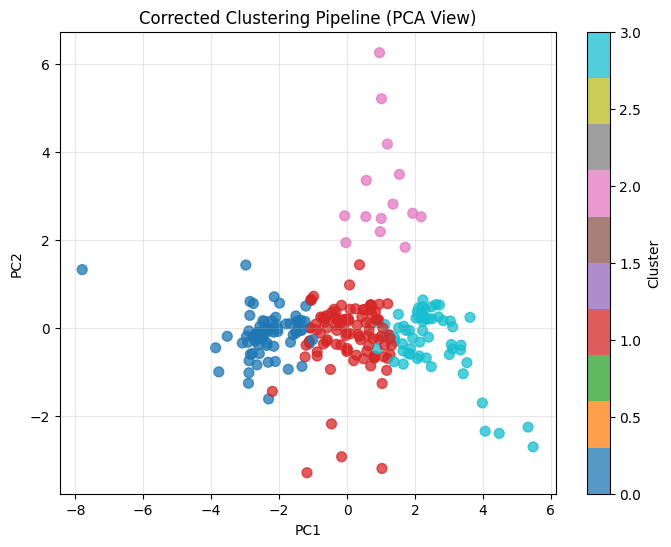

Verification checkpoints:

Standardized means:
[-0.  0. -0.  0.  0. -0.  0. -0. -0.]

Standardized std dev:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]

PC1 variance explained: 42.3%
Silhouette score: 0.2250
Cluster sizes: [ 72 100  14  61]


In [9]:
# ------------------------------------------------------------
# YOUR TASK — Write the corrected clustering pipeline
# Fix all four errors from Part 1
# ------------------------------------------------------------

# Step 1: Standardize features

available_cols = [col for col in feature_names if col in df.columns]

X = df[available_cols].copy()

# convert to numeric
for col in available_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# fill missing values
X = X.fillna(X.median())

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized.")
print()

# Step 2: Fit K-Means with correct parameter name and random_state

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)

print("K-Means completed.")
print()

# Step 3: Apply PCA to STANDARDIZED data

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Visualize PCA scatter plot colored by cluster

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='tab10',
    s=50,
    alpha=0.75
)

plt.title("Corrected Clustering Pipeline (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

print("Verification checkpoints:")
print()

print("Standardized means:")
print(X_scaled.mean(axis=0).round(4))
print()

print("Standardized std dev:")
print(X_scaled.std(axis=0).round(4))
print()

print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]:.1%}")

print(f"Silhouette score: {silhouette_score(X_scaled, labels):.4f}")

print(f"Cluster sizes: {np.bincount(labels)}")

---

## Part 3: EXTEND — Customer Segmentation with Synthetic Data

Move beyond country-level data. In this section, you apply clustering to
a **customer segmentation** problem using synthetic behavioral data.
This mirrors how fintechs like Nubank (Chapter 22 opening hook) discover
customer archetypes from transaction patterns.

Then compare **PCA** and **UMAP** for dimensionality reduction.

In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Generate synthetic customer data with 4 latent segments
# -----------------------------------------------------------

from sklearn.datasets import make_blobs

np.random.seed(42)

# Create 4 customer segments with 6 behavioral features
n_customers = 2000
segment_centers = [
    [50, 5, 80, 10, 2, 30],    # Budget-conscious: low spend, few txns, high app usage
    [200, 20, 40, 50, 8, 70],   # Power users: high spend, many txns
    [120, 12, 60, 30, 5, 50],   # Moderate users
    [300, 30, 20, 80, 12, 90],  # Premium: very high spend, low app engagement
]

X_cust, y_true = make_blobs(
    n_samples=n_customers,
    centers=segment_centers,
    cluster_std=[15, 25, 20, 20],
    random_state=42
)

cust_features = [
    'avg_monthly_spend', 'txn_frequency', 'app_sessions',
    'credit_utilization', 'products_held', 'digital_engagement'
]

cust_df = pd.DataFrame(X_cust, columns=cust_features)
cust_df['true_segment'] = y_true

print(f'Customers: {len(cust_df)}')
print(f'Features: {cust_features}')
print(f'True segments: {cust_df["true_segment"].value_counts().sort_index().to_dict()}')
print()
print(cust_df[cust_features].describe().round(1))

Customers: 2000
Features: ['avg_monthly_spend', 'txn_frequency', 'app_sessions', 'credit_utilization', 'products_held', 'digital_engagement']
True segments: {0: 500, 1: 500, 2: 500, 3: 500}

       avg_monthly_spend  txn_frequency  app_sessions  credit_utilization  \
count             2000.0         2000.0        2000.0              2000.0   
mean               167.4           16.7          50.2                41.7   
std                 94.6           22.2          30.4                33.0   
min                 10.5          -51.4         -58.4               -43.8   
25%                 80.3            1.1          26.9                15.4   
50%                155.2           15.7          52.3                38.8   
75%                251.2           31.5          74.8                67.0   
max                355.4           91.7         123.2               138.3   

       products_held  digital_engagement  
count         2000.0              2000.0  
mean             6.1         

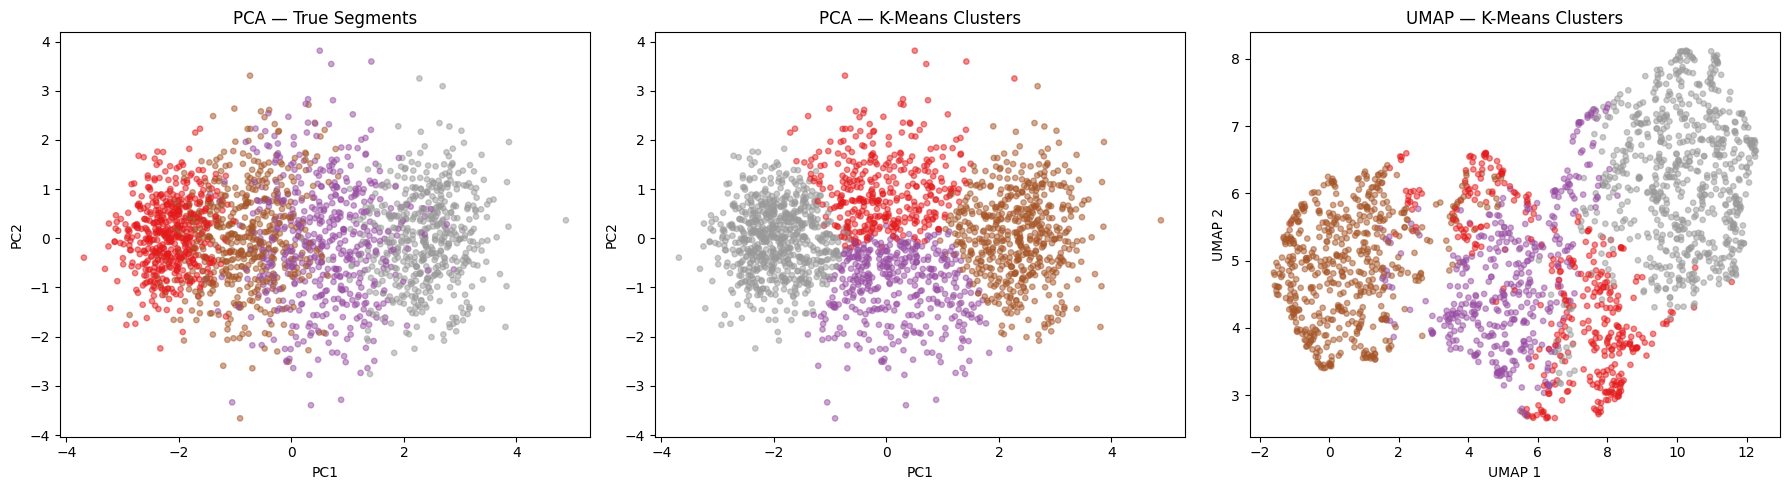

Silhouette score (K-Means K=4): 0.2387

Compare PCA vs UMAP: Which gives better visual separation?
UMAP often preserves local structure better than PCA for non-linear data.


In [11]:
# ------------------------------------------------------------
# YOUR TASK — Cluster customers and compare PCA vs UMAP
# ------------------------------------------------------------

import umap.umap_ as umap

# Step 1: Standardize customer features
cust_scaler = StandardScaler()
X_cust_scaled = cust_scaler.fit_transform(cust_df[cust_features])

# Step 2: Fit K-Means with K=4
km_cust = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
cust_df['kmeans_cluster'] = km_cust.fit_predict(X_cust_scaled)

# Step 3: PCA projection
pca_cust = PCA(n_components=2, random_state=42)
X_pca_cust = pca_cust.fit_transform(X_cust_scaled)

# Step 4: UMAP projection
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap_cust = reducer.fit_transform(X_cust_scaled)

# Step 5: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: PCA with TRUE labels
scatter1 = axes[0].scatter(
    X_pca_cust[:, 0], X_pca_cust[:, 1],
    c=cust_df['true_segment'],
    cmap='Set1',
    alpha=0.5, s=15
)
axes[0].set_title('PCA — True Segments', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Panel 2: PCA with K-MEANS labels
scatter2 = axes[1].scatter(
    X_pca_cust[:, 0], X_pca_cust[:, 1],
    c=cust_df['kmeans_cluster'],
    cmap='Set1',
    alpha=0.5, s=15
)
axes[1].set_title('PCA — K-Means Clusters', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Panel 3: UMAP with K-MEANS labels
scatter3 = axes[2].scatter(
    X_umap_cust[:, 0], X_umap_cust[:, 1],
    c=cust_df['kmeans_cluster'],
    cmap='Set1',
    alpha=0.5, s=15
)
axes[2].set_title('UMAP — K-Means Clusters', fontsize=12)
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

# Silhouette comparison
sil_kmeans = silhouette_score(X_cust_scaled, cust_df['kmeans_cluster'])
print(f"Silhouette score (K-Means K=4): {sil_kmeans:.4f}")
print()
print("Compare PCA vs UMAP: Which gives better visual separation?")
print("UMAP often preserves local structure better than PCA for non-linear data.")

---

## Part 4: Module Output — `clustering_utils.py`

Write a reusable Python module with three functions for clustering pipelines.
This is a **portfolio artifact** that demonstrates production-grade unsupervised learning.

### Requirements

```python
# clustering_utils.py

def run_kmeans_pipeline(df, features, k, random_state=42):
    """End-to-end K-Means pipeline: standardize, fit, return labels + metadata."""
    ...

def evaluate_k_range(X, k_range, random_state=42):
    """Compute WCSS and silhouette scores for a range of K values."""
    ...

def plot_pca_clusters(X, labels, feature_names):
    """PCA 2D scatter with cluster coloring + loadings annotation."""
    ...
```

Labels shape: (200,)
Silhouette: 0.7042
   k        wcss  silhouette
0  2  470.310385    0.533297
1  3  116.586704    0.704157
2  4  106.509332    0.541274
3  5   96.499161    0.386755
4  6   87.202574    0.220064
5  7   81.411995    0.218579


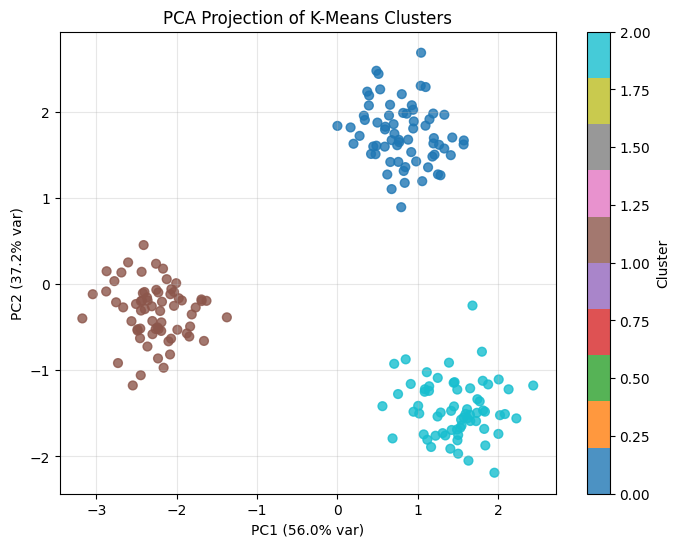

Self-test passed.


In [12]:
# ------------------------------------------------------------
# YOUR TASK — Write clustering_utils.py
# Implement the three functions below
# ------------------------------------------------------------

# %%writefile clustering_utils.py

"""
clustering_utils.py — Reusable Clustering Pipeline Module

Functions for standardized K-Means clustering, K evaluation,
and PCA visualization.

Author: [Your Name]
Course: ECON 5200, Lab 22
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from typing import List, Dict


def run_kmeans_pipeline(
    df: pd.DataFrame,
    features: List[str],
    k: int,
    random_state: int = 42
) -> Dict:
    """
    End-to-end K-Means pipeline.

    1. Extracts features from DataFrame
    2. Standardizes with StandardScaler
    3. Fits K-Means
    4. Returns labels, scaler, model, and metrics

    Returns:
        dict with keys:
        'labels', 'scaler', 'model', 'X_scaled', 'silhouette', 'inertia'
    """
    # select columns
    X = df[features].copy()

    # ensure numeric
    for col in features:
        X[col] = pd.to_numeric(X[col], errors='coerce')

    # fill missing values
    X = X.fillna(X.median())

    # standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # fit kmeans
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_state)
    labels = model.fit_predict(X_scaled)

    # metrics
    sil = silhouette_score(X_scaled, labels)
    inertia = model.inertia_

    return {
        "labels": labels,
        "scaler": scaler,
        "model": model,
        "X_scaled": X_scaled,
        "silhouette": sil,
        "inertia": inertia
    }


def evaluate_k_range(
    X: np.ndarray,
    k_range: range,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Evaluate clustering quality across a range of K values.

    Returns:
        DataFrame with columns: 'k', 'wcss', 'silhouette'
    """
    results = []

    for k in k_range:
        model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_state)
        labels = model.fit_predict(X)

        # silhouette only valid when k >= 2 and more than 1 cluster exists
        sil = silhouette_score(X, labels)

        results.append({
            "k": k,
            "wcss": model.inertia_,
            "silhouette": sil
        })

    return pd.DataFrame(results)


def plot_pca_clusters(
    X: np.ndarray,
    labels: np.ndarray,
    feature_names: List[str]
) -> None:
    """
    PCA 2D scatter plot with cluster coloring.

    Fits PCA(n_components=2), creates scatter plot colored by cluster,
    and annotates with explained variance ratios.
    """
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="tab10",
        s=40,
        alpha=0.8
    )

    plt.title("PCA Projection of K-Means Clusters")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    plt.show()


# ---- Quick self-test ----
if __name__ == "__main__":
    from sklearn.datasets import make_blobs

    X_test, _ = make_blobs(
        n_samples=200,
        centers=3,
        n_features=5,
        random_state=0
    )
    df_test = pd.DataFrame(X_test, columns=[f"f{i}" for i in range(5)])

    result = run_kmeans_pipeline(df_test, [f"f{i}" for i in range(5)], k=3)
    print(f"Labels shape: {result['labels'].shape}")
    print(f"Silhouette: {result['silhouette']:.4f}")

    eval_df = evaluate_k_range(result["X_scaled"], range(2, 8))
    print(eval_df)

    plot_pca_clusters(result["X_scaled"], result["labels"], [f"f{i}" for i in range(5)])
    print("Self-test passed.")

---

## Challenge: Hierarchical Clustering Comparison

K-Means assumes spherical clusters and requires you to specify K upfront.
**Agglomerative hierarchical clustering** builds a tree (dendrogram) of
nested clusters and lets you choose K after inspecting the tree.

Compare K-Means and Agglomerative clustering on the WDI data:
1. Fit `AgglomerativeClustering(n_clusters=4)` on the standardized WDI data
2. Plot the dendrogram using `scipy.cluster.hierarchy`
3. Compare cluster assignments with K-Means — do they agree?

Agglomerative cluster sizes:
0     68
1    124
2     40
3     15
Name: count, dtype: int64



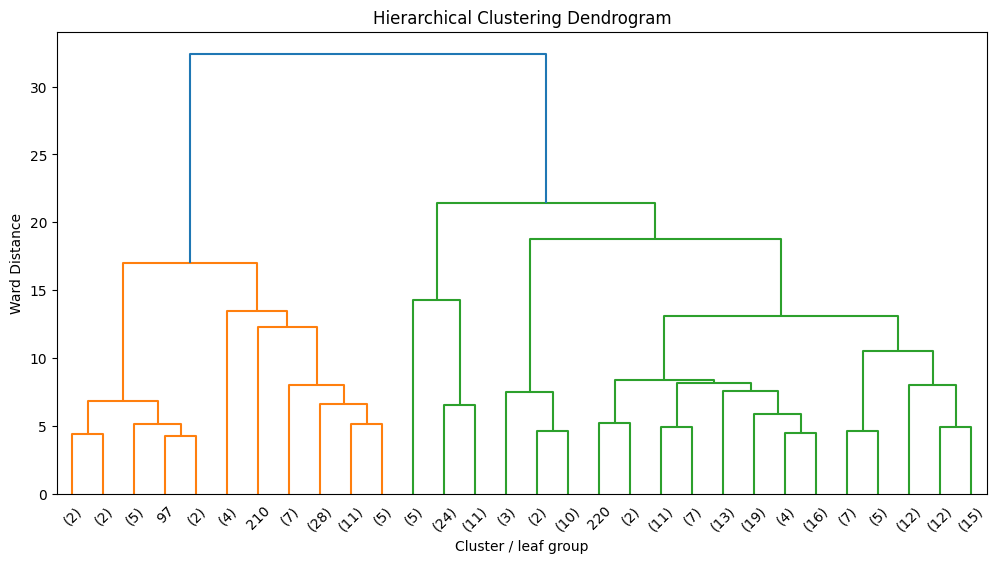

Cross-tabulation: K-Means vs Agglomerative
Agglomerative   0   1   2   3
KMeans                       
0              59  13   0   0
1               9  90   0   1
2               0   0   0  14
3               0  21  40   0

K-Means silhouette score:        0.2250
Agglomerative silhouette score: 0.2042

K-Means performs slightly better based on silhouette score.


In [13]:
# ------------------------------------------------------------
# CHALLENGE — Hierarchical clustering + dendrogram
# ------------------------------------------------------------

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Fit agglomerative clustering on standardized data
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

print("Agglomerative cluster sizes:")
print(pd.Series(agg_labels).value_counts().sort_index())
print()

# Step 2: Plot dendrogram
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / leaf group")
plt.ylabel("Ward Distance")
plt.show()

# Step 3: Cross-tabulate K-Means vs Agglomerative labels
# Use the K-Means labels created earlier in Part 2
kmeans_labels = labels

comparison = pd.crosstab(
    pd.Series(kmeans_labels, name="KMeans"),
    pd.Series(agg_labels, name="Agglomerative")
)

print("Cross-tabulation: K-Means vs Agglomerative")
print(comparison)
print()

# Step 4: Compare silhouette scores
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_agg = silhouette_score(X_scaled, agg_labels)

print(f"K-Means silhouette score:        {sil_kmeans:.4f}")
print(f"Agglomerative silhouette score: {sil_agg:.4f}")
print()

if sil_kmeans > sil_agg:
    print("K-Means performs slightly better based on silhouette score.")
elif sil_agg > sil_kmeans:
    print("Agglomerative clustering performs slightly better based on silhouette score.")
else:
    print("Both methods have the same silhouette score.")